In [21]:
# tf floers dataset(5종 꽃 이미지)으로 전이학습 + 미세조정

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

(train_ds, val_ds), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

for image, label in train_ds.take(1):
    print(type(image), type(label))

print(ds_info.features['label'].names)

<class 'tensorflow.python.framework.ops.EagerTensor'> <class 'tensorflow.python.framework.ops.EagerTensor'>
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [22]:
# 전처리
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def preprocessFunc(image, label):
  image = tf.image.resize(image, IMG_SIZE)
  image = tf.cast(image, tf.float32) / 255.0
  return image, label

train_ds = train_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocessFunc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 백본(base model) 불러오기
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3, ),
    include_top=False,
    weights='imagenet',
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,   # 학습에 참여 없이 특징 추출기(Conv + Pool)의 역할만 함
    layers.GlobalAveragePooling2D(),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=ds_info.features['label'].num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(base_model.summary())
print(model.summary())

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [23]:
model.fit(train_ds, validation_data= val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f'loss: {loss:.4f}, acc: {acc:.4f}')

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.8007 - loss: 0.5502 - val_accuracy: 0.8828 - val_loss: 0.3253
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 861ms/step - accuracy: 0.9179 - loss: 0.2383 - val_accuracy: 0.8910 - val_loss: 0.3156
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 797ms/step - accuracy: 0.9632 - loss: 0.1357 - val_accuracy: 0.8924 - val_loss: 0.3502
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 89s 872ms/step - accuracy: 0.9833 - loss: 0.0842 - val_accuracy: 0.8815 - val_loss: 0.3708
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 868ms/step - accuracy: 0.9867 - loss: 0.0609 - val_accuracy: 0.8787 - val_loss: 0.3727
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 878ms/step - accuracy: 0.8787 - loss: 0.3727
loss: 0.3727, acc: 0.8787


In [24]:
# 다음 단계 - Fine tunning(base model의 일부 레이어만 학습에 참여)
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print('미세 조정 시작 ....')
model.fit(train_ds, validation_data= val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f'fine tunning : loss: {loss:.4f}, acc: {acc:.4f}')



미세 조정 시작 ....
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8191 - loss: 0.5116 - val_accuracy: 0.8856 - val_loss: 0.3635
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8382 - loss: 0.4480 - val_accuracy: 0.8842 - val_loss: 0.3582
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8552 - loss: 0.3999 - val_accuracy: 0.8815 - val_loss: 0.3535
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8668 - loss: 0.3659 - val_accuracy: 0.8801 - val_loss: 0.3484
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8828 - loss: 0.3310 - val_accuracy: 0.8828 - val_loss: 0.3466
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8828 - loss: 0.3466
fine tunning : loss: 0.3466, acc: 0.8828


In [26]:
# 검증 데이터 셋에서 이미지 한 개 추출
for image, label in val_ds.take(1):
  sample_image = image
  sample_label = label
  break

pred_probs = model.predict(sample_image)
print(pred_probs)

pred_classes = tf.argmax(pred_probs, axis=1)
print(pred_classes)



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[1.04468145e-05 9.49797322e-06 4.43396362e-04 5.98490878e-04
  9.98938143e-01]
 [4.63257765e-10 4.09097787e-08 9.99989808e-01 5.87522742e-09
  1.01101095e-05]
 [7.00375240e-04 3.07555729e-06 9.27856684e-01 1.06865894e-02
  6.07531257e-02]
 [1.41581893e-06 1.95949241e-07 9.99967158e-01 8.34047569e-07
  3.03207489e-05]
 [5.14197387e-02 9.48515058e-01 3.09868170e-07 6.40408252e-05
  8.51290679e-07]
 [5.72679222e-01 1.56933486e-01 2.34592636e-03 8.56620551e-04
  2.67184824e-01]
 [2.71455497e-02 9.63338912e-01 5.79066761e-03 3.30715068e-03
  4.17746167e-04]
 [1.25808031e-09 5.69520919e-09 9.99817133e-01 2.60163863e-10
  1.83009586e-04]
 [5.96851285e-04 1.91180478e-03 1.07883650e-03 9.96316850e-01
  9.56792428e-05]
 [8.82883526e-08 1.23036742e-07 8.15779913e-07 9.99995172e-01
  3.71345186e-06]
 [7.14403752e-04 3.26668918e-02 1.29654340e-03 9.63449571e-03
  9.55687582e-01]
 [6.47318957e-04 3.09343559e-05 5.43558598e-03 9.93768156e-01
  1.18006574e-04]
 [3.

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
[00] pred : 4 (roses) | actual : 4 (roses)
[01] pred : 2 (tulips) | actual : 2 (tulips)
[02] pred : 2 (tulips) | actual : 2 (tulips)
[03] pred : 2 (tulips) | actual : 2 (tulips)
[04] pred : 1 (daisy) | actual : 1 (daisy)
[05] pred : 0 (dandelion) | actual : 1 (daisy)
[06] pred : 1 (daisy) | actual : 1 (daisy)
[07] pred : 2 (tulips) | actual : 2 (tulips)
[08] pred : 3 (sunflowers) | actual : 3 (sunflowers)
[09] pred : 3 (sunflowers) | actual : 3 (sunflowers)
[10] pred : 4 (roses) | actual : 4 (roses)
[11] pred : 3 (sunflowers) | actual : 3 (sunflowers)
[12] pred : 3 (sunflowers) | actual : 3 (sunflowers)
[13] pred : 2 (tulips) | actual : 2 (tulips)
[14] pred : 2 (tulips) | actual : 2 (tulips)
[15] pred : 0 (dandelion) | actual : 0 (dandelion)
[16] pred : 2 (tulips) | actual : 2 (tulips)
[17] pred : 0 (dandelion) | actual : 0 (dandelion)
[18] pred : 3 (sunflowers) | actual : 3 (sunflowers)
[19] pred : 0 (dandelion) | actual : 0 (dan

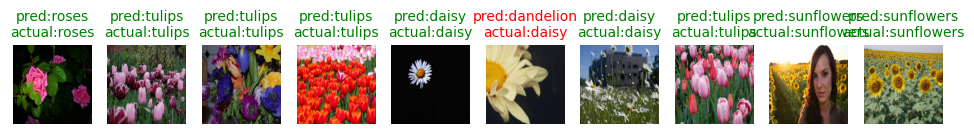

In [31]:
# 클래스 이름 얻기
class_names = ds_info.features['label'].names
print(class_names)

# 예측값과 실제값 출력
for i in range(len(sample_image)):
    predict_index = int(pred_classes[i])
    actual_index = int(sample_label[i])

    predict_name = class_names[predict_index]
    actual_name = class_names[actual_index]

    print(f'[{i:02}] pred : {predict_index} ({predict_name}) | actual : {actual_index} ({actual_name})')

# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(sample_image[i])

  predicted_label = class_names[int(pred_classes[i])]
  actual_label = class_names[int(sample_label[i])]

  color = 'green' if predicted_label == actual_label else 'red'
  plt.title(f'pred:{predicted_label}\nactual:{actual_label}', color=color, fontsize=10)
  plt.axis('off')

plt.show()